# (노트) 경사하강법 (2차원), 텐서플로우

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- categories: [데이터과학]

`-` 이번에는 아래와 같은 함수를 고려하여 보자. 

$$(x_1\beta_1+x_2\beta_2-y)^2=(\beta_1+\beta_2-2)^2$$

우리는 이미 최적값을 알고 있다. $(\beta_1,\beta_2)=(1,1)$에서 최저값을 가질 것이다. 이 최저값을 경사하강법으로 찾는다고 하면 

(1) 적당한 값으로 $(\beta_1,\beta_2)$를 초기화 한다. 

(2) 초기값 $\beta_1$, $\beta_2$에서 각각 0.01씩 빼거나 더해보면서 loss를 계산하고 유리한 방향을 선택하여 움직인다. 

`-` 이때 (2)의 과정을 좀 더 자세히 생각해보면 아래와 같다. 
 - (i) $\beta_2$는 고정하고 $\beta_1$에서 0.01씩 더하거나 빼보면서 더하는것이 유리한지 빼는것이 유리한지 판단한다. 
 - (ii) $\beta_1$을 고정하고 $\beta_2$에서 0.01씩 더하거나 빼보면서 더하는것이 유리한지 빼는것이 유리한지 판단한다. 

(i)의 과정은 사실상 $\beta_1$으로 편미분하는 과정이고 (ii)의 과정은 사실상 $\beta_2$로 편미분하는 과정이다. 

`-` 방향이 결정되었다면 각각의 방향으로 얼만큼 이동할지를 결정해야하는데, 이는 편미분의 계수로 판단한다. 예를들어 $\beta_1$을 0.01만큼 변화시키는 것이 $\beta_2$를 0.01만큼 변화시키는것보다 손실함수 감소폭이 2배 더 크다면 $\beta_1$을 $\beta_2$보다 더 많이 수정하는것이 유리하다. 예컨데 이러한 상황에서는 $\beta_1$을 0.02씩 변화시키고 $\beta_2$는 0.01을 변화시켜야 맞다. 즉 

$${\boldsymbol \beta}_{new} \leftarrow {\boldsymbol \beta}_{old}+\begin{bmatrix} 0.02 \\ 0.01 \end{bmatrix}$$

와 같이 말이다. 여기에서 $\begin{bmatrix} 0.02 \\ 0.01 \end{bmatrix}$은 학습률과 그레디언트의 곱으로 해석할 수 있다. 즉 아래와 같이 볼 수 있다. 

$$\begin{bmatrix} 0.02 \\ 0.01 \end{bmatrix}= - \alpha \begin{bmatrix} \frac{\partial }{\partial \beta_1} \\ \frac{\partial }{\partial \beta_2} \end{bmatrix}loss(\beta_1,\beta_2)$$

#### 경사하강법에 대한 비판 

`-` 손실함수의 모양이 아래와 같다고 하자. 

$$loss=\beta(\beta-1)(\beta-3)(\beta-3.01)$$

그림을 그려보면 아래와 같다.

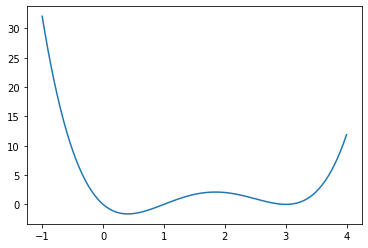

In [14]:
beta=np.linspace(-1,4,100)
loss=beta*(beta-1)*(beta-3)*(beta-3.01)
plt.plot(beta,loss)

이러한 모양의 함수는 경사하강법으로 반드시 최소점을 구할 수 있다고 장담할 수 없다. (극소점을 찾을수는 있음) 

`-` 최소점을 찾지 못하고 극소점에 갇히는 경우를 전역최소점(global minimum)찾지 못하고 국소최소점(local minumum)을 찾는 경우라고 표현한다. 

`-` 경사하강법으로 찾은 해가 전역최소점임을 주장하기 위해서는 함수의 모양이 

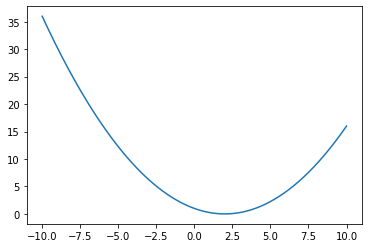

In [15]:
beta=np.linspace(-10,10,1000)
loss=(beta*0.5-1)**2
import matplotlib.pyplot as plt 
plt.plot(beta,loss)

와 같은 모양이어야 하는데 (아래로 볼록한 이차함수) 이러한 함수를 convex 함수라고 한다. 

`-` 즉 손실함수가 convex일 경우에 경사하강법으로 찾은 해가 의미가 있다. 

`-` 참고: 모든 선형모형은 손실함수가 convex이다. 

#### 경사하강법에 대한 비판2 

`-` 이번의 비판은 다소 실용적인 측면에서의 비판이다. 

`-` 예제로 들어왔던 

$$loss(\beta)=(x\beta-y)^2$$

이런 모양의 손실함수와 다르게 우리가 실제로 고민해야할 손실함수의 형태는 아래와 같다. 

$$loss(\beta)=\sum_{i=1}^{n}(x_i\beta-y_i)^2$$

가령 $n$개의 관측치가 있고 각 관측치가 $(2,3), \dots (6,8.7)$ 이라면 

$$loss(\beta)=(2\beta-3)^2+\dots+(6\beta-8.7)^2$$

이다. 

`-` 학습을 하는 도중에 데이터가 추가되어 $n+1$이 되었다고 하자. 경사하강법은 모든 샘플을 사용하여 기울기를 구하는 알고리즘이므로, 이 경우 학습하던것을 중단하고 처음부터 $n+1$개의 자료를 고려해서 다시 기울기를 계산해야 한다. 

### 방법3: Stochastic gradient descent

`-` 일반적으로 경사하강법은 모든 샘플($n$개의샘플)을 활용하여 $\beta$ 혹은 ${\bf w}$를 업데이트한다. 이러한 방법을 `배치학습`이라고 부른다. 

`-` 이와 대조적으로 극단적으로 샘플 하나만을 사용하여 파라메터를 업데이트 하는 방법이 있는데 이를 `확률적경사하강법`이라고 부른다. 
 - 보통 머리글자를 따서 SGD라고 표현한다. 

`-` 대략적인 알고리즘은 아래와 같다. 

(1) $n$개의 샘플의 순서를 섞는다. 

(2) $1\sim n$까지 관측치 하나에 대한 loss만 계산하여 $\beta$를 업데이트한다. (따라서 $n$번 업데이트가 된다) 

(3) (2)의 모든과정이 끝나면 (하나의 세대, 하나의 에폭이 끝났다고 말한다) 다시 (1)로 돌아가서 샘플의 순서를 섞고 반복한다. 

### 방법4: mini-batch gradient descent 

`–` 방법2와 방법3은 너무 양 극단의 방법처럼 느껴진다. 경사하강법은 모든샘플을 사용하고 (즉 $n$개의 샘플을 사용하고), 확률적경사하강법은 1개의 샘플만 사용한다. 두 방법의 절충안으로 미니배치 기법이 존재한다. 

`-` 구체적인 알고리즘은 아래와 같다. 

***[알고리즘]***

(1) $n$개의 자료에서 무작위로 $m$의 샘플을 추출한다. 

(2) $m$개의 샘플을 전체 자료라고 생각하고 경사하강법을 수행한다. 

(3) 다시 1로 돌아가서 $m$의 샘플을 무작위로 추출한다. 수렴할때까지 이 과정을 반복한다. 

`-` 배치와 스토캐스틱 방식은 세대마다 훈련집합의 모든 샘플이 빠지지 않고 충실히 참여하여 기울기를 계산한다. 

`-` 미니배치방식은 운에 따라서 임의의 샘플들이 착출된다. 

`-` 따라서 운에 따라 모든 학습이 완료될때까지 훈련과정 (=손실함수의 기울기를 계산하고 $\beta$ 혹은 $\bf w$를 업데이트하는 과정) 에 한번도 참여하지 않는 샘플이 있을 수 있다. 

`-` 그렇지만 미니배치가 전체 샘플의 대표성을 가지므로 미니배치로 훈련해도 해를 잘 찾는다. 

***[다른버전의 알고리즘]*** : 훈련집합을 모두 사용하게끔 미니배치를 구성하는 알고리즘도 존재함. 

(1) 훈련집합을 미니배치 단위로 나눈다. 

(2) 미니배치를 순서대로 처리한다. 

`-` 모든 샘플이 참여한다. 그런데 연관성이 높은 자료들이 연속적으로 저장될 수 있으니 미니배치로 나누기전에 순서를 충분히 섞어준다. 

### 경사하강법, 확률적 경사하강법, 미니배치 기법

`-` 속도: 미니배치 기법이 가장 빠르다. 

`-` 수렴모양: 확률적경사하강법은 갈팡질팡하면서 수렴하는 모양이다. 배치기법은 안정적으로 수렴하는 모양새이다. 미니배치는 그 중간. 

`-` 전역해/국소해
 - 손실함수가 컨벡스일 경우는 경사하강법이 해를 안정적으로 잘 찾는다. 확률적경사하강법은 최소점 근처에서 갈팡질팡할 수 있다. 미니배치는 그 양 극단의 중간이다. 
 - 손실함수가 컨벡스가 아닐 경우는 경사하강법은 국소해로 빠진다. (국소해를 잘찾는다라고 해석해야할듯) 확률적경사하강법은 국소해에서 갈팡질팡 하다가 국소해를 운좋게 탈출할 수 있다. 미니배치는 그 중간. 

`-` 온라인학습 (중간에 샘플이 추가되는 경우) 

- 경사하강법: 처음부터 다시 학습한다. 
- 미니배치/확률적경사하강법: 이어서 학습해도 상관없다. (온라인 학습에 더 유리하다기보다, 온라인 학습이어도 상관없다는 뉘앙스)

### 용어 정리 및 결론 

#### 결론

`-` 대세는 미니배치이다. 

####  용어정리 

`-` 경사하강법을 지칭하는 용어는 명확하다. 

`-` 미니배치가 애매한데 엄밀히 말하면 미니배치에서도 확률적인 요소가 들어가기 떄문에 mini-batch stochastic gradient descent 라고 쓰는것이 엄밀하다. 

`-` 하지만 확률적 경사하강법에 비하여 미니배치 확률적 경사하강법이 훨씬 폭넓게 쓰이므로 사실상 미니배치를 활용한 방법을 확률적 경사하강법이라 설명하는 문헌도 있다. 

`-` 또한 미니배치 알고리즘 중 변형된 형태는 모든 샘플이 참여하게끔 하는 버전도 있는데 이때 batch-size=1로 설정하면 이는 확률적 경사하강법과 동일하게 된다. 이러한 이유로 확률적경사하강법을 미니배치의 일부로 설명하는 문헌도 가끔씩 있다. 